# BBB Dataset — EDA, Preprocessing, and Training (up to model fit)

This notebook builds a clean, well‑documented ML pipeline for the BBB dataset, including EDA (with plots), preprocessing, and model training (no evaluation yet).

## 🔍 Goals
- Load the dataset and confirm schema
- Perform EDA with key plots
- Build a clean preprocessing pipeline
- Train baseline models (Logistic Regression + SVM)

> We’ll stop after training; evaluation and SHAP come later.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



sns.set_theme(style="whitegrid")

## 1) Load dataset and inspect schema

In [18]:
data_path = "BBB_dataset.tsv"

df = pd.read_csv(data_path, sep="\t", low_memory=False)

print("Shape:", df.shape)
print("Columns:", len(df.columns))

non_numeric_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

display(df.head(2))

Shape: (7807, 1625)
Columns: 1625
Non-numeric columns: ['compound_name', 'IUPAC_name', 'SMILES', 'BBB+/BBB-', 'Inchi', 'reference', 'group', 'comments']


,NO.,compound_name,IUPAC_name,SMILES,CID,logBB,BBB+/BBB-,Inchi,threshold,reference,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,1,sulphasalazine,2-hydroxy-5-[[4-(pyridin-2-ylsulfamoyl)phenyl]...,O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O,5339.0,-2.69,BBB-,InChI=1S/C18H14N4O5S/c23-16-9-6-13(11-15(16)18...,NaN,R2|R2|R25|R46|,...,10.171643,63.201012,398.068491,9.477821,2428,42,144,165,9.590278,6.097222
1,2,moxalactam,7-[[2-carboxy-2-(4-hydroxyphenyl)acetyl]amino]...,COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...,3889.0,-2.52,BBB-,InChI=1S/C20H20N6O9S/c1-25-19(22-23-24-25)36-8...,NaN,R25|,...,10.893010,87.033695,520.101247,9.287522,4114,62,194,237,13.756944,7.916667


## 2) EDA — target distribution

BBB+/BBB-
BBB+    4956
BBB-    2851
Name: count, dtype: int64


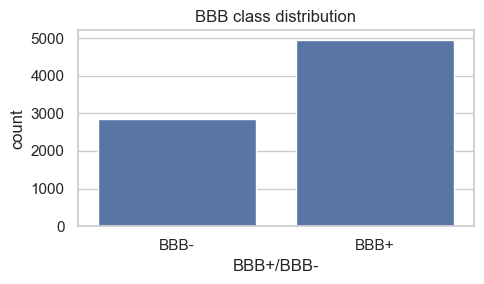

Imbalance ratio (BBB+ / BBB-): 1.74


In [19]:
target_col = "BBB+/BBB-"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

# Count + plot class distribution
class_counts = df[target_col].value_counts(dropna=False)
print(class_counts)

plt.figure(figsize=(5, 3))
sns.countplot(x=target_col, data=df)
plt.title("BBB class distribution")
plt.tight_layout()
plt.show()

# Imbalance ratio
if "BBB+" in class_counts and "BBB-" in class_counts:
    ratio = class_counts["BBB+"] / class_counts["BBB-"]
    print(f"Imbalance ratio (BBB+ / BBB-): {ratio:.2f}")

**Interpretation & action:** If the classes are imbalanced (ratio far from 1), we’ll use `class_weight="balanced"` for classifiers like Logistic Regression and SVM.

Displaying Null values

In [20]:
pd.set_option("display.max_rows", None)
display(df.isnull().sum())

NO.                  0
compound_name     1109
IUPAC_name        1637
SMILES               0
CID               1637
logBB             6749
BBB+/BBB-            0
Inchi                0
threshold         4186
reference            0
group                0
comments          7789
ABC                  0
ABCGG                0
nAcid                0
nBase                0
SpAbs_A             10
SpMax_A             10
SpDiam_A            10
SpAD_A              10
SpMAD_A             10
LogEE_A             10
VE1_A               10
VE2_A               10
VE3_A               10
VR1_A               10
VR2_A               10
VR3_A               17
nAromAtom            0
nAromBond            0
nAtom                0
nHeavyAtom           0
nSpiro               0
nBridgehead          0
nHetero              0
nH                   0
nB                   0
nC                   0
nN                   0
nO                   0
nS                   0
nP                   0
nF                   0
nCl        

## 3) EDA — missingness overview

Columns with missing values: 886
NO.                  0
compound_name     1109
IUPAC_name        1637
SMILES               0
CID               1637
logBB             6749
BBB+/BBB-            0
Inchi                0
threshold         4186
reference            0
group                0
comments          7789
ABC                  0
ABCGG                0
nAcid                0
nBase                0
SpAbs_A             10
SpMax_A             10
SpDiam_A            10
SpAD_A              10
SpMAD_A             10
LogEE_A             10
VE1_A               10
VE2_A               10
VE3_A               10
VR1_A               10
VR2_A               10
VR3_A               17
nAromAtom            0
nAromBond            0
nAtom                0
nHeavyAtom           0
nSpiro               0
nBridgehead          0
nHetero              0
nH                   0
nB                   0
nC                   0
nN                   0
nO                   0
nS                   0
nP                   0
n

MINsGeH3     1.0
MINaaSe      1.0
MINsNH3      1.0
MAXsssSnH    1.0
MINssNH2     1.0
MAXssSnH2    1.0
MINsssAs     1.0
MAXsSnH3     1.0
MAXddssSe    1.0
MINsssNH     1.0
dtype: float64

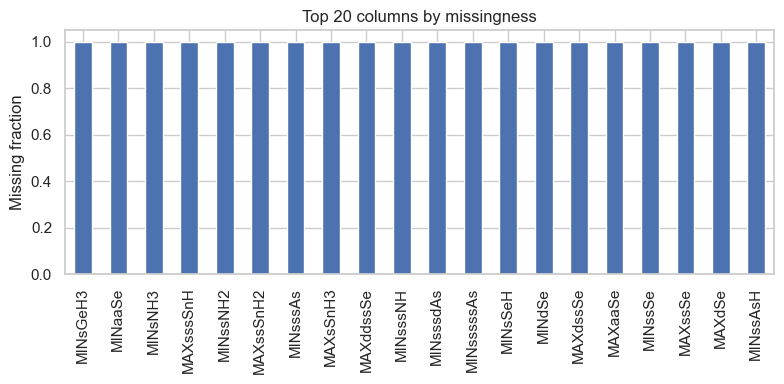

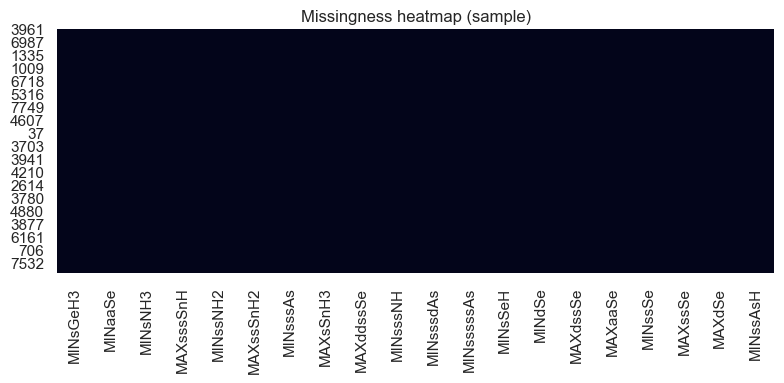

In [46]:
missing_pct = df.isna().mean().sort_values(ascending=False)
missing_summary = missing_pct[missing_pct > 0]

print(f"Columns with missing values: {missing_summary.shape[0]}")
print(df.isnull().sum())
display(missing_summary.head(10))

# Plot top 20 missingness columns
plt.figure(figsize=(8, 4))
missing_summary.head(20).plot(kind="bar")
plt.title("Top 20 columns by missingness")
plt.ylabel("Missing fraction")
plt.tight_layout()
plt.show()

# Heatmap on a small sample + top missing columns (for readability)
top_missing_cols = missing_summary.head(20).index.tolist()
if top_missing_cols:
    sample_df = df[top_missing_cols].sample(n=min(300, len(df)), random_state=42)
    plt.figure(figsize=(8, 4))
    sns.heatmap(sample_df.isna(), cbar=False)
    plt.title("Missingness heatmap (sample)")
    plt.tight_layout()
    plt.show()

### Missingness buckets (0%, >50%, 100%)

In [47]:
missing_counts = df.isna().sum()
row_count = len(df)

fully_missing = missing_counts[missing_counts == row_count].index.tolist()
mostly_missing = missing_counts[missing_counts > 0.5 * row_count].index.tolist()
no_missing = missing_counts[missing_counts == 0].index.tolist()

print("Fully missing columns:", len(fully_missing))
print("Mostly missing (>50%) columns:", len(mostly_missing))
print("No-missing columns:", len(no_missing))

# Show a few examples
print("\nFully missing (sample):", fully_missing[:10])
print("Mostly missing (sample):", mostly_missing[:10])
print("No missing (sample):", no_missing[:10])

Fully missing columns: 76
Mostly missing (>50%) columns: 153
No-missing columns: 739

Fully missing (sample): ['MAXsLi', 'MAXssBe', 'MAXssssBe', 'MAXssBH', 'MAXssssB', 'MAXsNH3', 'MAXssNH2', 'MAXsssNH', 'MAXssSiH2', 'MAXsssSiH']
Mostly missing (sample): ['logBB', 'threshold', 'comments', 'MAXsLi', 'MAXssBe', 'MAXssssBe', 'MAXssBH', 'MAXsssB', 'MAXssssB', 'MAXdCH2']
No missing (sample): ['NO.', 'SMILES', 'BBB+/BBB-', 'Inchi', 'reference', 'group', 'ABC', 'ABCGG', 'nAcid', 'nBase']


**Interpretation & action:** Many descriptors have missing values, so we’ll use median imputation and drop columns that are entirely missing.

## 5) EDA — correlation snapshot (top-variance features)

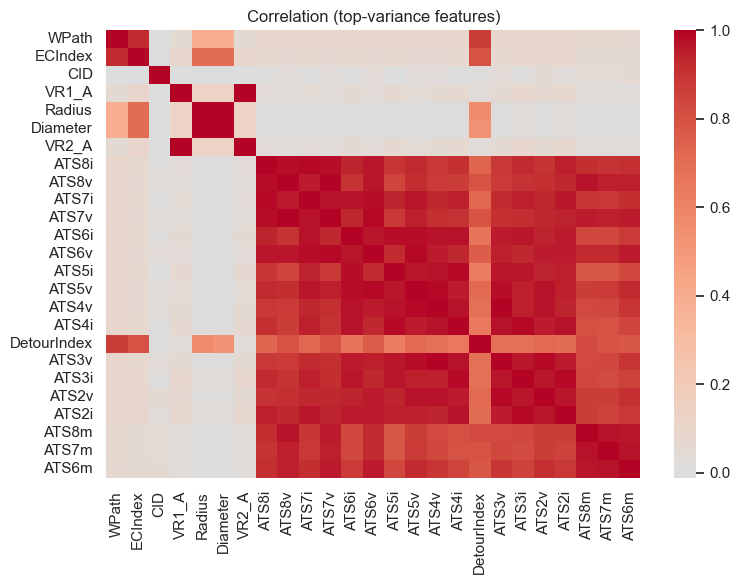

In [48]:
numeric_df = df.select_dtypes(include=["number"]).copy()

# Pick top-variance features to keep the heatmap readable
variances = numeric_df.var(numeric_only=True).sort_values(ascending=False)
top_features = variances.head(25).index

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df[top_features].corr(), cmap="coolwarm", center=0)
plt.title("Correlation (top-variance features)")
plt.tight_layout()
plt.show()

### Full correlation table (top-variance features)

In [49]:
corr_table = numeric_df[top_features].corr()
display(corr_table)

,WPath,ECIndex,CID,VR1_A,Radius,Diameter,VR2_A,ATS8i,ATS8v,ATS7i,...,ATS4v,ATS4i,DetourIndex,ATS3v,ATS3i,ATS2v,ATS2i,ATS8m,ATS7m,ATS6m
WPath,1.000000,0.922296,-0.005906,0.051388,0.395120,0.395120,0.050210,0.089335,0.088588,0.089412,...,0.084631,0.090381,0.867955,0.089423,0.096548,0.094893,0.102237,0.076100,0.072162,0.067911
ECIndex,0.922296,1.000000,-0.007869,0.101876,0.698973,0.698973,0.100899,0.072466,0.071063,0.072108,...,0.069934,0.077235,0.802228,0.074744,0.082484,0.080525,0.089317,0.059792,0.055797,0.051741
CID,-0.005906,-0.007869,1.000000,-0.006556,-0.011400,-0.011399,-0.006914,0.012884,0.028423,0.012859,...,0.028799,0.004086,0.012945,0.034437,0.008825,0.048053,0.025569,0.040645,0.042397,0.056339
VR1_A,0.051388,0.101876,-0.006556,1.000000,0.128574,0.133557,0.999979,0.034735,0.027550,0.040263,...,0.054820,0.068644,0.030979,0.060029,0.080350,0.064043,0.074121,0.020404,0.020940,0.022788
Radius,0.395120,0.698973,-0.011400,0.128574,1.000000,1.000000,0.128157,0.010857,0.008852,0.009060,...,0.007263,0.014042,0.574641,0.008922,0.016938,0.013256,0.023412,0.004374,0.001531,-0.001429
Diameter,0.395120,0.698973,-0.011399,0.133557,1.000000,1.000000,0.133123,0.010858,0.008852,0.009060,...,0.007264,0.014043,0.536118,0.008923,0.016939,0.013257,0.023412,0.004374,0.001532,-0.001429
VR2_A,0.050210,0.100899,-0.006914,0.999979,0.128157,0.133123,1.000000,0.034169,0.026983,0.039677,...,0.054286,0.068105,0.030249,0.059479,0.079809,0.063469,0.073568,0.019864,0.020413,0.022244
ATS8i,0.089335,0.072466,0.012884,0.034735,0.010857,0.010858,0.034169,1.000000,0.976681,0.984679,...,0.888362,0.911538,0.729354,0.885768,0.926326,0.900080,0.948651,0.919732,0.900560,0.911753
ATS8v,0.088588,0.071063,0.028423,0.027550,0.008852,0.008852,0.026983,0.976681,1.000000,0.955655,...,0.874046,0.871879,0.801871,0.877720,0.897430,0.907144,0.929963,0.973952,0.945098,0.945843
ATS7i,0.089412,0.072108,0.012859,0.040263,0.009060,0.009060,0.039677,0.984679,0.955655,1.000000,...,0.933436,0.945042,0.722011,0.926831,0.950383,0.929789,0.964182,0.894518,0.885685,0.915123


Feature imp of all cols

Dropped columns (13):
['BBB+/BBB-', 'CID', 'Diameter', 'IUPAC_name', 'Inchi', 'NO.', 'SMILES', 'VR2_A', 'comments', 'compound_name', 'group', 'logBB', 'reference']

Training features used: 1612
Top feature importances (Decision Tree, all non-leak cols):


,importance
TopoPSA,0.353306
MAXsOH,0.047540
Kier3,0.030640
ATSC4v,0.026150
ATSC1c,0.013774
...,...
BCUTare-1h,0.000000
BCUTpe-1h,0.000000
BCUTse-1h,0.000000
BCUTm-1l,0.000000


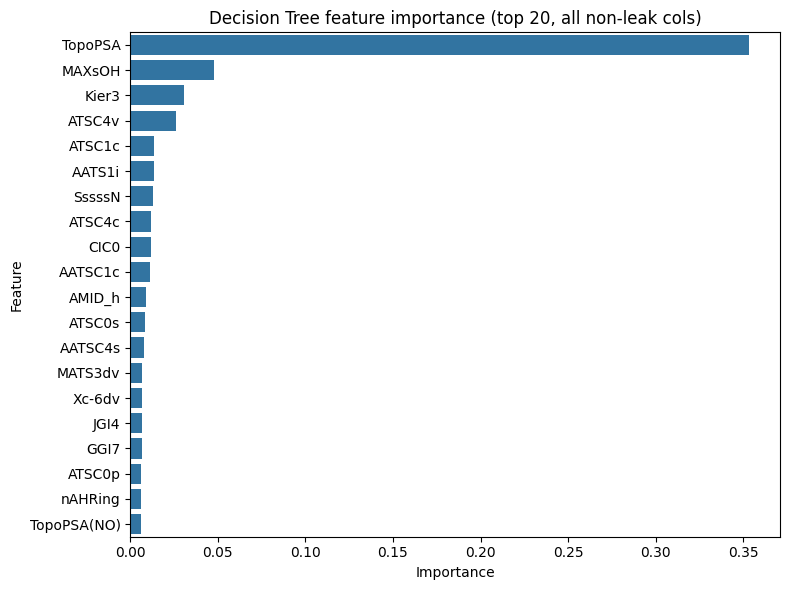

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

# Make cell self-contained if notebook kernel was restarted
if "df" not in globals():
    df = pd.read_csv("BBB_dataset.tsv", sep="\t", low_memory=False)

# --- Build "all columns except leaked" feature set ---
target_col = "BBB+/BBB-"
y_all = df[target_col].map({"BBB+": 1, "BBB-": 0})

# Non-feature IDs / metadata
default_id_cols = [
    "NO.", "compound_name", "IUPAC_name", "SMILES", "CID",
    "Inchi", "reference", "comments", "group"
]

# Reuse leak columns identified earlier if available (fallback to known list)
leaked_cols = list(explicit_drop) if "explicit_drop" in globals() else ["Diameter", "VR2_A", "CID"]

# Extra guard: remove obvious target/proxy leak columns if present
# (e.g., any BBB label variants and logBB-style permeability proxy columns)
leak_keywords = ["bbb", "logbb", "label", "target", "class"]
pattern_leak_cols = [
    c for c in df.columns
    if c != target_col and any(k in c.lower() for k in leak_keywords)
]

drop_cols = sorted(set([target_col] + default_id_cols + leaked_cols + pattern_leak_cols))
existing_drop_cols = [c for c in drop_cols if c in df.columns]

X_all = df.drop(columns=existing_drop_cols, errors="ignore").copy()

# Keep rows with valid target mapping only
valid_idx = y_all.notna()
X_all = X_all.loc[valid_idx]
y_all = y_all.loc[valid_idx].astype(int)

# One-hot encode categorical cols (if any), then impute
X_all_encoded = pd.get_dummies(X_all, drop_first=False)
X_all_encoded = X_all_encoded.replace([np.inf, -np.inf], np.nan)
X_all_encoded = X_all_encoded.fillna(X_all_encoded.median(numeric_only=True))
X_all_encoded = X_all_encoded.fillna(0)

# Train Decision Tree on all remaining (non-leak) features
dt_all = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=3
)
dt_all.fit(X_all_encoded, y_all)

# Feature importance table (all cols)
dt_importances = pd.Series(dt_all.feature_importances_, index=X_all_encoded.columns)
dt_importances = dt_importances.sort_values(ascending=False)

print(f"Dropped columns ({len(existing_drop_cols)}):")
print(existing_drop_cols)
print(f"\nTraining features used: {X_all_encoded.shape[1]}")
print("Top feature importances (Decision Tree, all non-leak cols):")
display(dt_importances.to_frame("importance"))

# Plot top 20
plt.figure(figsize=(8, 6))
sns.barplot(x=dt_importances.head(20).values, y=dt_importances.head(20).index)
plt.title("Decision Tree feature importance (top 20, all non-leak cols)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Actual Project**


=== Random Forest Performance ===
Accuracy: 0.8924
F1 Score: 0.9177
ROC AUC: 0.9607

Dropped columns (13):
['BBB+/BBB-', 'CID', 'Diameter', 'IUPAC_name', 'Inchi', 'NO.', 'SMILES', 'VR2_A', 'comments', 'compound_name', 'group', 'logBB', 'reference']

Training features used: 1612

Top feature importances (Random Forest):


,importance
TopoPSA,0.013533
TopoPSA(NO),0.013322
nHetero,0.011022
MID_h,0.010541
ATSC0c,0.009284
...,...
MAXaaSe,0.000000
MAXssSe,0.000000
MAXdSe,0.000000
MAXsSeH,0.000000


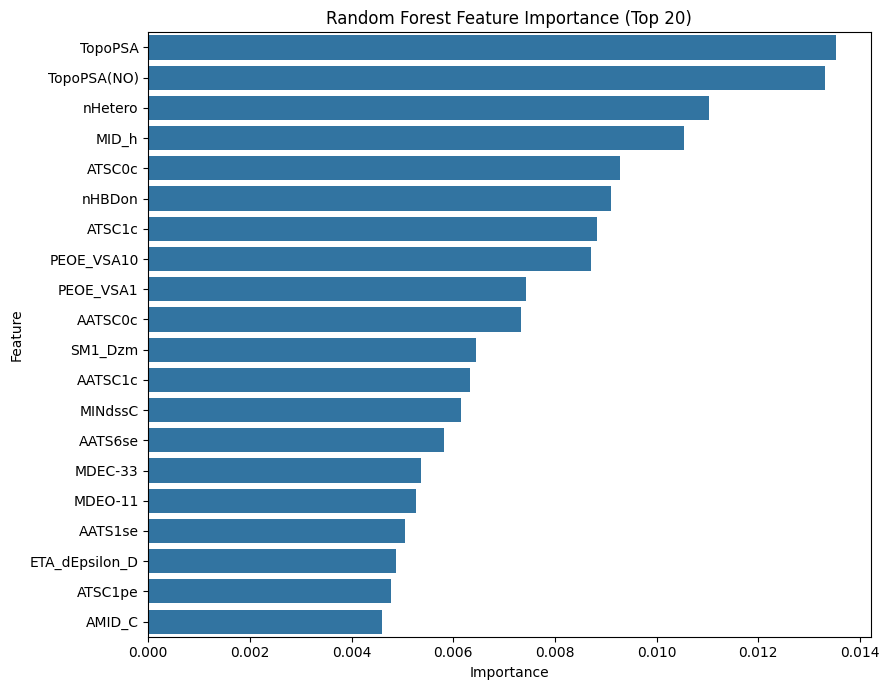

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# =========================
# 1. Load + preprocess data
# =========================
if "X_all_encoded" not in globals() or "y_all" not in globals():
    if "df" not in globals():
        df = pd.read_csv("BBB_dataset.tsv", sep="\t", low_memory=False)

    target_col = "BBB+/BBB-"
    y_all = df[target_col].map({"BBB+": 1, "BBB-": 0})

    # Columns to drop (IDs + leakage)
    default_id_cols = [
        "NO.", "compound_name", "IUPAC_name", "SMILES", "CID",
        "Inchi", "reference", "comments", "group"
    ]

    leaked_cols = list(explicit_drop) if "explicit_drop" in globals() else ["Diameter", "VR2_A", "CID"]

    leak_keywords = ["bbb", "logbb", "label", "target", "class"]
    pattern_leak_cols = [
        c for c in df.columns
        if c != target_col and any(k in c.lower() for k in leak_keywords)
    ]

    drop_cols = sorted(set([target_col] + default_id_cols + leaked_cols + pattern_leak_cols))
    existing_drop_cols = [c for c in drop_cols if c in df.columns]

    # Features
    X_all = df.drop(columns=existing_drop_cols, errors="ignore").copy()

    # Remove missing targets
    valid_idx = y_all.notna()
    X_all = X_all.loc[valid_idx]
    y_all = y_all.loc[valid_idx].astype(int)

    # Encoding
    X_all_encoded = pd.get_dummies(X_all, drop_first=False)

    # Clean infinities + NaNs
    X_all_encoded = X_all_encoded.replace([np.inf, -np.inf], np.nan)
    X_all_encoded = X_all_encoded.fillna(X_all_encoded.median(numeric_only=True))
    X_all_encoded = X_all_encoded.fillna(0)

# =========================
# 2. Train-test split
# =========================
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_all_encoded,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# =========================
# 3. Train Random Forest
# =========================
rf_all = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_all.fit(X_train_rf, y_train_rf)

# =========================
# 4. Evaluation
# =========================
y_pred_rf = rf_all.predict(X_test_rf)

accuracy = accuracy_score(y_test_rf, y_pred_rf)
f1 = f1_score(y_test_rf, y_pred_rf)

print("\n=== Random Forest Performance ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# ROC AUC
try:
    y_proba_rf = rf_all.predict_proba(X_test_rf)[:, 1]
    roc_auc = roc_auc_score(y_test_rf, y_proba_rf)
    print(f"ROC AUC: {roc_auc:.4f}")
except Exception as e:
    print(f"ROC AUC not available: {e}")

# =========================
# 5. Feature Importance
# =========================
rf_importances = pd.Series(
    rf_all.feature_importances_,
    index=X_train_rf.columns
).sort_values(ascending=False)

print(f"\nDropped columns ({len(existing_drop_cols)}):")
print(existing_drop_cols)

print(f"\nTraining features used: {X_train_rf.shape[1]}")
print("\nTop feature importances (Random Forest):")
display(rf_importances.to_frame("importance"))

# =========================
# 6. Plot top 20 features
# =========================
top_n = 20

plt.figure(figsize=(9, 7))
sns.barplot(
    x=rf_importances.head(top_n).values,
    y=rf_importances.head(top_n).index
)

plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 11) SVM feature importance via permutation importance (recommended)

Permutation importance is the best general-purpose approach for non-linear SVMs (like RBF):
- It works with any estimator.
- It measures the actual performance drop when each feature is shuffled.
- It avoids model-structure bias from tree-based split mechanics.


--FAILURE

**Trying L1 logistic regression method**

### Logistic Regression with L1 (feature selection)

L1 regularization shrinks many coefficients to exactly zero, so non-zero coefficients are the selected features to keep note of.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Load data
df = pd.read_csv("BBB_dataset.tsv", sep="\t", low_memory=False)

# 2. Target
y = df["BBB+/BBB-"].map({"BBB+": 1, "BBB-": 0})

# 3. Drop unwanted columns (IDs + leakage)
drop_cols = [
    "BBB+/BBB-", "NO.", "compound_name", "IUPAC_name",
    "SMILES", "CID", "Inchi", "reference", "comments",
    "group", "logBB"
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])

# 4. Handle missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train L1 Logistic Regression
model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=5000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

# 8. Evaluate
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("=== L1 Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

# 9. Get feature importance
coef = pd.Series(model.coef_[0], index=X.columns)

# Keep only important features (non-zero)
selected_features = coef[coef != 0]

print("\nTotal features:", X.shape[1])
print("Selected features:", len(selected_features))

print("\nTop 20 important features:")
print(selected_features.abs().sort_values(ascending=False).head(20))

=== L1 Logistic Regression ===
Accuracy: 0.8597951344430218
F1 Score: 0.8888888888888888
ROC AUC: 0.9316196236559139

Total features: 1614
Selected features: 289

Top 20 important features:
SssssN            0.456559
MDEC-33           0.438030
PEOE_VSA6         0.398819
EState_VSA5       0.376799
ATSC6are          0.359491
ETA_dEpsilon_D    0.317956
AATS4dv           0.308293
Lipinski          0.296880
JGI1              0.290483
nBase             0.285314
SaasC             0.277364
nG12ARing         0.274287
C3SP2             0.269263
GATS2p            0.268877
AATSC1i           0.266704
Kier3             0.261526
GATS6d            0.255267
MAXsOH            0.253999
PEOE_VSA9         0.241311
GATS7se           0.238636
dtype: float64


### SVM (RBF) on top 50 L1-selected features

Use the top 50 features ranked by L1 absolute coefficient, then train and evaluate an RBF SVM on that reduced feature set.

In [2]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Select top 50 features from L1 output
top50_features = selected_features.abs().sort_values(ascending=False).head(50).index.tolist()

X_train_sel = X_train[top50_features]
X_test_sel = X_test[top50_features]

# 2. Train SVM
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=True)
)

svm_model.fit(X_train_sel, y_train)

# 3. Evaluate
y_pred = svm_model.predict(X_test_sel)
y_prob = svm_model.predict_proba(X_test_sel)[:, 1]

print("=== SVM (Top 50 Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

# 4. Show features
print("\nTop 50 features:")
print(top50_features)

=== SVM (Top 50 Features) ===
Accuracy: 0.881562099871959
F1 Score: 0.9061390157280568
ROC AUC: 0.9343166383701189

Top 50 features:
['SssssN', 'MDEC-33', 'PEOE_VSA6', 'EState_VSA5', 'ATSC6are', 'ETA_dEpsilon_D', 'AATS4dv', 'Lipinski', 'JGI1', 'nBase', 'SaasC', 'nG12ARing', 'C3SP2', 'GATS2p', 'AATSC1i', 'Kier3', 'GATS6d', 'MAXsOH', 'PEOE_VSA9', 'GATS7se', 'SssCH2', 'CIC1', 'Xch-5d', 'nAcid', 'SsCH3', 'AATS3p', 'PEOE_VSA5', 'AETA_beta_ns_d', 'MATS6c', 'n4AHRing', 'GATS3p', 'MINsssN', 'VE2_Dzp', 'BCUTi-1h', 'BCUTdv-1h', 'JGI5', 'n6ARing', 'GATS8c', 'MATS6dv', 'ATSC3dv', 'MATS5s', 'VSA_EState3', 'ATSC4Z', 'MDEC-44', 'MATS2d', 'GATS8i', 'NsOH', 'SsssN', 'MATS7se', 'MDEO-11']


**SVM non linear trained on Top 20 features**

In [9]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Select top 20 features (from L1 output)
top20_features = selected_features.abs().sort_values(ascending=False).head(20).index.tolist()

X_train_sel = X_train[top20_features]
X_test_sel = X_test[top20_features]

# 2. Train SVM
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=True)
)

svm_model.fit(X_train_sel, y_train)

# 3. Evaluate
y_pred = svm_model.predict(X_test_sel)
y_prob = svm_model.predict_proba(X_test_sel)[:, 1]

print("=== SVM (Top 20 Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

# 4. Show features used
print("\nTop 20 features:")
print(top20_features)

=== SVM (Top 20 Features) ===
Accuracy: 0.8713188220230473
F1 Score: 0.8981246832235175
ROC AUC: 0.9213037634408603

Top 20 features:
['SssssN', 'MDEC-33', 'PEOE_VSA6', 'EState_VSA5', 'ATSC6are', 'ETA_dEpsilon_D', 'AATS4dv', 'Lipinski', 'JGI1', 'nBase', 'SaasC', 'nG12ARing', 'C3SP2', 'GATS2p', 'AATSC1i', 'Kier3', 'GATS6d', 'MAXsOH', 'PEOE_VSA9', 'GATS7se']


**Compress top 20 into 8 based on PCA**

### PCA compression: top 20 features → 8 components

Take the top 20 L1-ranked features, reduce them to 8 principal components, and train an RBF SVM on the compressed representation.

In [15]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ==============================
# 0. Use EXISTING selected_features
# ==============================
# selected_features already computed earlier

print("Using precomputed L1-selected features...")

# ==============================
# 1. Select top 20 from L1 results
# ==============================
top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print("Top 20 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ==============================
# 2. Scaling
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# ==============================
# 3. PCA (20 → 8)
# ==============================
pca = PCA(n_components=8)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

# ==============================
# 4. Linear SVM
# ==============================
print("\nTraining Linear SVM...")

model = SVC(
    kernel="linear",
    C=0.5,
    class_weight="balanced",
    probability=True
)

model.fit(X_train_pca, y_train)

# ==============================
# 5. Evaluation
# ==============================
y_pred = model.predict(X_test_pca)
y_prob = model.predict_proba(X_test_pca)[:, 1]

print("\n=== Linear SVM (PCA 20 → 8) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

# ==============================
# 6. Diagnostics
# ==============================
print("\nNumber of support vectors:", len(model.support_))
print("Sample predictions:", y_pred[:10])

Using precomputed L1-selected features...
Top 20 features: ['GATS6d', 'ATSC5pe', 'ATSC5are', 'SssssN', 'GATS5p', 'GGI7', 'MAXtsC', 'nBondsD', 'GATS1p', 'SsCH3', 'GATS8i', 'MATS5s', 'ATSC6c', 'MATS6p', 'GGI3', 'nARing', 'GGI4', 'GGI2', 'AATSC8i', 'MATS1c']

Explained variance ratio: [0.26902757 0.12939599 0.09012614 0.06907108 0.06556242 0.06471277
 0.05047373 0.04682235]
Total variance explained: 0.7851920366277909

Training Linear SVM...

=== Linear SVM (PCA 20 → 8) ===
Accuracy: 0.7144686299615877
F1 Score: 0.7689119170984456
ROC AUC: 0.7644489247311828

Number of support vectors: 4333
Sample predictions: [0 1 0 1 0 0 0 1 0 0]


**QML part**

In [20]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# ==============================
# 1. Select top 8 features (from L1)
# ==============================
top_features = selected_features.abs().sort_values(ascending=False).head(8).index.tolist()

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ==============================
# 2. Scale (NO PCA)
# ==============================
scaler = StandardScaler()
X_train_q = scaler.fit_transform(X_train_sel)
X_test_q = scaler.transform(X_test_sel)

print("Using top 8 original features (no PCA)")

# ==============================
# 3. Reduce dataset size
# ==============================
X_train_q, _, y_train_q, _ = train_test_split(
    X_train_q, y_train,
    train_size=60,
    random_state=42,
    stratify=y_train
)

X_test_q, _, y_test_q, _ = train_test_split(
    X_test_q, y_test,
    train_size=30,
    random_state=42,
    stratify=y_test
)

print("Train size:", len(X_train_q), "| Test size:", len(X_test_q))

# ==============================
# 4. Quantum Kernel + QSVC
# ==============================
feature_map = ZZFeatureMap(feature_dimension=8, reps=2,entanglement="linear")

kernel = FidelityQuantumKernel(feature_map=feature_map)

model = QSVC(quantum_kernel=kernel)
model.fit(X_train_q, y_train_q)

# ==============================
# 5. Evaluation
# ==============================
y_pred = model.predict(X_test_q)

print("\n=== Quantum SVM (Top 8 Features) ===")
print("Accuracy:", accuracy_score(y_test_q, y_pred))
print("F1 Score:", f1_score(y_test_q, y_pred))

try:
    y_score = model.decision_function(X_test_q)
    print("ROC AUC:", roc_auc_score(y_test_q, y_score))
except:
    print("ROC AUC not available")

Using top 8 original features (no PCA)
Train size: 60 | Test size: 30

=== Quantum SVM (Top 8 Features) ===
Accuracy: 0.6333333333333333
F1 Score: 0.7755102040816326
ROC AUC: 0.5263157894736842


In [23]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# ==============================
# 1. Same feature selection
# ==============================
top_features = selected_features.abs().sort_values(ascending=False).head(8).index.tolist()

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ==============================
# 2. Same scaling
# ==============================
scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_sel)
X_test_svm = scaler.transform(X_test_sel)

print("Using top 8 features (same as QSVC)")

# ==============================
# 3. Same dataset size
# ==============================
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_svm, y_train,
    train_size=500,
    random_state=42,
    stratify=y_train
)

X_test_svm, _, y_test_svm, _ = train_test_split(
    X_test_svm, y_test,
    train_size=30,
    random_state=42,
    stratify=y_test
)

print("Train size:", len(X_train_svm), "| Test size:", len(X_test_svm))

# ==============================
# 4. Linear SVM
# ==============================
model = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced",
    probability=True
)

model.fit(X_train_svm, y_train_svm)

# ==============================
# 5. Evaluation
# ==============================
y_pred = model.predict(X_test_svm)
y_prob = model.predict_proba(X_test_svm)[:, 1]

print("\n=== Linear SVM (Top 8 Features) ===")
print("Accuracy:", accuracy_score(y_test_svm, y_pred))
print("F1 Score:", f1_score(y_test_svm, y_pred))
print("ROC AUC:", roc_auc_score(y_test_svm, y_prob))

Using top 8 features (same as QSVC)
Train size: 500 | Test size: 30

=== Linear SVM (Top 8 Features) ===
Accuracy: 0.7333333333333333
F1 Score: 0.8
ROC AUC: 0.722488038277512
